# Random Forest from Scratch

A decision tree classifies by asking a sequence of yes/no questions about one feature at a time.
Each internal node holds a feature and a threshold and sends a sample left if
$x_j \le \tau$ and right otherwise. Each leaf holds a class. Training means choosing, at every
node, the one question that best separates the classes below it.

"Best" is measured by **Gini impurity**. For a node holding a set of labels where a proportion
$p_c$ belong to class $c$,

$$G = 1 - \sum_{c} p_c^2$$

$G = 0$ when every sample at the node has the same label, and for two classes it is at its largest,
$0.5$, when the split is 50/50. It is the probability that two samples drawn at random from the
node have different labels.

A candidate split divides $n$ samples into a left part of size $n_L$ and a right part of size
$n_R$. The gain is the parent impurity minus the impurity of the two children, each weighted by
how many samples it received:

$$\Delta G = G(\text{parent}) - \frac{n_L}{n}G(L) - \frac{n_R}{n}G(R)$$

The tree tries every feature and every threshold available to it and keeps the pair maximising
$\Delta G$, then recurses on each side. The weighting matters: a split that produces one perfectly
pure child of 2 samples and one messy child of 200 has barely improved anything, and multiplying by
$n_L/n$ and $n_R/n$ says so.

**Entropy** is the usual alternative criterion,

$$H = -\sum_c p_c \log_2 p_c$$

used in the same $\Delta G$ formula in place of $G$. It peaks at $1$ for a two-class 50/50 node
rather than $0.5$, and it punishes near-pure nodes slightly harder because of the logarithm, but the
two curves have the same shape and almost always pick the same split. Gini is used here because it
avoids computing logarithms.

A single tree grown to full depth memorises its training set. A **random forest** fixes that by
training many trees on perturbed versions of the problem and averaging them, which is developed
further down once the tree itself is working.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

BLUE = '#2a78d6'
ORANGE = '#eb6834'
AQUA = '#1baf7a'

np.random.seed(42)

## Loading the data

The cell downloads the UCI Heart Disease data - 303 patients, 13 features. `ca` (number of major
vessels coloured by fluoroscopy) is missing on 4 rows and `thal` on 2, so features and target are
joined into one frame before `dropna` runs, which keeps the two aligned and leaves 297 rows.

The target column `num` records severity from 0 to 4. The standard treatment of this dataset is
presence against absence, so `num > 0` collapses it into a binary label: 0 for no heart disease,
1 for heart disease of any severity.

The features are a mixture of types. `cp` (chest pain type), `restecg`, `slope` and `thal` are
nominal codes; `sex`, `fbs` (fasting blood sugar above 120) and `exang` (exercise-induced angina)
are binary; `age`, `trestbps` (resting blood pressure), `chol` (cholesterol), `thalach` (maximum
heart rate) and `oldpeak` (ST depression) are continuous on wildly different scales; `ca` is a count
from 0 to 3. **No scaling is applied.** A tree only ever compares one feature against a threshold
drawn from that same feature, so the units of one column never meet the units of another. That is a
real advantage of trees over distance-based or gradient-based models, which all need the columns put
on a common scale first.

In [2]:
heart = fetch_ucirepo(id=45)

feature_names = list(heart.data.features.columns)

# join before dropping so features and target stay aligned
frame = pd.concat([heart.data.features, heart.data.targets], axis=1).dropna()

X = frame[feature_names].values.astype(float)
y = (frame['num'].values > 0).astype(int)   # 0 = absence, 1 = presence

print('rows before dropping missing:', len(heart.data.features))
print('rows after: ', len(X))
print('features:   ', len(feature_names))
print(feature_names)
print()
print('absence (0):  ', (y == 0).sum())
print('presence (1): ', (y == 1).sum())

rows before dropping missing: 303
rows after:  297
features:    13
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

absence (0):   160
presence (1):  137


## The dataset at a glance

Three panels. The first is the class balance, which is close to even at 160 against 137 - a model
that always guessed "absence" would score 53.9%, so that is the number to beat. The second overlays
the maximum heart rate `thalach` for each class, and the third does the same for `age`. Both are
drawn as histograms split by label to show how much a single feature separates the classes on its
own: `thalach` separates them noticeably, `age` barely at all.

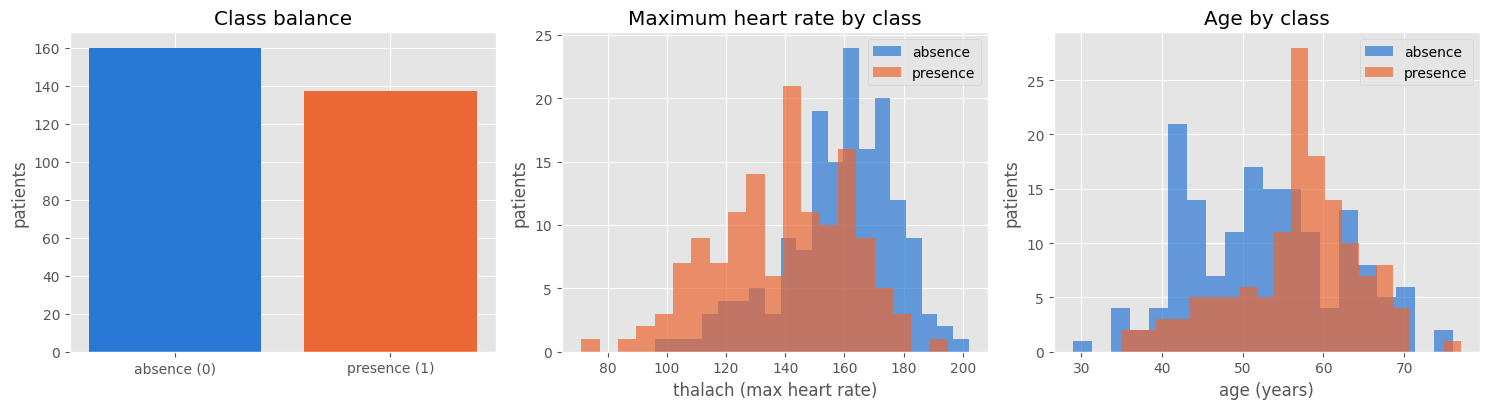

always-guess-absence baseline: 0.5387


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

ax[0].bar(['absence (0)', 'presence (1)'], [(y == 0).sum(), (y == 1).sum()],
          color=[BLUE, ORANGE])
ax[0].set_ylabel('patients')
ax[0].set_title('Class balance')

thalach = X[:, feature_names.index('thalach')]
ax[1].hist(thalach[y == 0], bins=20, color=BLUE, alpha=0.7, label='absence')
ax[1].hist(thalach[y == 1], bins=20, color=ORANGE, alpha=0.7, label='presence')
ax[1].set_xlabel('thalach (max heart rate)')
ax[1].set_ylabel('patients')
ax[1].set_title('Maximum heart rate by class')
ax[1].legend()

age = X[:, feature_names.index('age')]
ax[2].hist(age[y == 0], bins=20, color=BLUE, alpha=0.7, label='absence')
ax[2].hist(age[y == 1], bins=20, color=ORANGE, alpha=0.7, label='presence')
ax[2].set_xlabel('age (years)')
ax[2].set_ylabel('patients')
ax[2].set_title('Age by class')
ax[2].legend()

plt.tight_layout()
plt.show()

print('always-guess-absence baseline:', round((y == 0).mean(), 4))

## Train/test split

`rng.permutation` shuffles the row indices with a fixed seed and the first 75% become the training
set, the rest the test set. Everything below is fitted on `X_train` only; `X_test` is touched once
per model to report a score.

In [4]:
rng = np.random.default_rng(42)
order = rng.permutation(len(y))
cut = int(0.75 * len(y))
train_idx, test_idx = order[:cut], order[cut:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('train:', X_train.shape, 'class counts', np.bincount(y_train))
print('test: ', X_test.shape, 'class counts', np.bincount(y_test))

train: (222, 13) class counts [120 102]
test:  (75, 13) class counts [40 35]


## Gini impurity

`gini` counts how many samples of each class are in a set of labels, turns those counts into
proportions and returns

$$G = 1 - \sum_{c} p_c^2$$

The cell prints it for the whole training set, for a pure set and for an even split, to show the
range. The training set sits near the top of that range, which is what makes it worth splitting.

In [5]:
def gini(labels):
    if len(labels) == 0:
        return 0.0
    p = np.bincount(labels, minlength=2) / len(labels)
    return 1.0 - np.sum(p ** 2)


print('training set     ', round(gini(y_train), 4))
print('all one class    ', round(gini(np.zeros(50, dtype=int)), 4))
print('even 50/50 split ', round(gini(np.array([0] * 50 + [1] * 50)), 4))

training set      0.4967
all one class     0.0
even 50/50 split  0.5


## The Decision_Tree class

`fit` records the training size, zeroes the `importances` accumulator and calls `grow`, which
builds the tree recursively and returns a dictionary per node.

`grow` first builds the node as if it were a leaf: `value` is the majority class from
`np.bincount`, along with the node's `gini`, its sample count `n` and the per-class `counts`. It
returns that leaf immediately if any stopping rule fires - the depth limit `max_depth` is reached,
fewer than `min_samples_split` samples remain, or the node is already pure.

Otherwise it picks which features to consider. `n_features` controls how many: left as `None` the
node sees all 13, and set to a smaller number `self.rng.choice` draws that many at random without
replacement. That single argument is what turns an ordinary tree into a forest tree.

`best_split` does the search. For each candidate feature it sorts the unique values in that column
and takes the midpoints between neighbouring ones as thresholds, so a threshold always falls between
two observed values rather than on one. For each threshold it forms the left mask `column <= thr`,
skips the split if either side is empty, and evaluates

$$\Delta G = G(\text{parent}) - \frac{n_L}{n}G(L) - \frac{n_R}{n}G(R)$$

keeping the largest. It returns `None` when no split improves on the parent, which turns the node
into a leaf.

Back in `grow`, the winning split is applied. Before recursing, the impurity decrease is added to
that feature's entry in `importances`, weighted by the fraction of the whole training set that
reached this node - a split near the root moves many samples and counts for more than an equally
clean split over 5 samples deep down. `fit` normalises the accumulator to sum to 1 at the end.

`predict` calls `walk` on each row, which starts at `self.root` and follows `left` or `right`
according to the stored feature and threshold until it hits a leaf, then returns that leaf's
`value`.

In [6]:
class Decision_Tree:
    def __init__(self, max_depth=10, min_samples_split=2, n_features=None, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.random_state = random_state

    def fit(self, X, y):
        self.rng = np.random.default_rng(self.random_state)
        self.n_total_features = X.shape[1]
        self.n_train = len(y)
        self.importances = np.zeros(self.n_total_features)
        self.root = self.grow(X, y, 0)
        if self.importances.sum() > 0:
            self.importances = self.importances / self.importances.sum()
        return self

    def grow(self, X, y, depth):
        n_samples = len(y)
        counts = np.bincount(y, minlength=2)
        node = {'leaf': True, 'value': int(np.argmax(counts)), 'gini': gini(y),
                'n': n_samples, 'counts': counts, 'depth': depth}

        if (depth >= self.max_depth or n_samples < self.min_samples_split
                or counts.max() == n_samples):
            return node

        # a forest tree only looks at a random subset of features here
        if self.n_features is None:
            feature_ids = np.arange(self.n_total_features)
        else:
            feature_ids = self.rng.choice(self.n_total_features, size=self.n_features,
                                          replace=False)

        best = self.best_split(X, y, feature_ids)
        if best is None:
            return node

        feature, threshold, decrease = best
        left = X[:, feature] <= threshold

        # weight the impurity drop by how much of the training set reached this node
        self.importances[feature] += decrease * n_samples / self.n_train

        node['leaf'] = False
        node['feature'] = feature
        node['threshold'] = threshold
        node['decrease'] = decrease
        node['left'] = self.grow(X[left], y[left], depth + 1)
        node['right'] = self.grow(X[~left], y[~left], depth + 1)
        return node

    def best_split(self, X, y, feature_ids):
        n = len(y)
        parent = gini(y)
        best_gain = 0.0
        best = None

        for feature in feature_ids:
            column = X[:, feature]
            values = np.unique(column)
            if len(values) < 2:
                continue

            # midpoints between neighbouring observed values
            thresholds = (values[:-1] + values[1:]) / 2.0

            for threshold in thresholds:
                left = column <= threshold
                n_left = left.sum()
                n_right = n - n_left
                if n_left == 0 or n_right == 0:
                    continue

                gain = parent - (n_left / n) * gini(y[left]) - (n_right / n) * gini(y[~left])
                if gain > best_gain:
                    best_gain = gain
                    best = (feature, threshold, gain)

        return best

    def predict(self, X):
        return np.array([self.walk(x, self.root) for x in X])

    def walk(self, x, node):
        while not node['leaf']:
            if x[node['feature']] <= node['threshold']:
                node = node['left']
            else:
                node = node['right']
        return node['value']

## Fitting one tree

The cell fits a single tree on the training set with `max_depth=10` and no feature restriction, so
every split considers all 13 features. It reports accuracy on the training set and on the test set.

The gap between the two is the point of the exercise: a tree given enough depth keeps splitting
until its leaves are pure, so training accuracy runs to 1.0 while test accuracy does not follow.

In [7]:
tree = Decision_Tree(max_depth=10, min_samples_split=2, random_state=1)
tree.fit(X_train, y_train)

tree_train_acc = (tree.predict(X_train) == y_train).mean()
tree_test_acc = (tree.predict(X_test) == y_test).mean()

print('single tree, train accuracy:', round(tree_train_acc, 4))
print('single tree, test accuracy: ', round(tree_test_acc, 4))

single tree, train accuracy: 1.0
single tree, test accuracy:  0.7733


## What the tree actually looks like

`node_label` turns a node dictionary into the text drawn inside its box: an internal node shows the
feature name and threshold it tests, its gini and how many samples reached it, and a leaf shows the
class it predicts instead.

`draw` walks the tree to a depth of 2 and places each node at a fixed slot - horizontal position by
position within the level, vertical position by depth - drawing a box and a line down to each child.
The box is coloured by the node's majority class. Below the plot, `show_text` prints the same
structure indented, going one level deeper; a node that the depth cut-off stops at rather than a
genuine leaf is marked as such, since the real tree continues underneath it.

Reading the root: everything about the model is in these boxes. The first question is the one that
separated the classes best out of all 13 features and every threshold in each, and both sides then
get the same treatment applied to whatever remains.

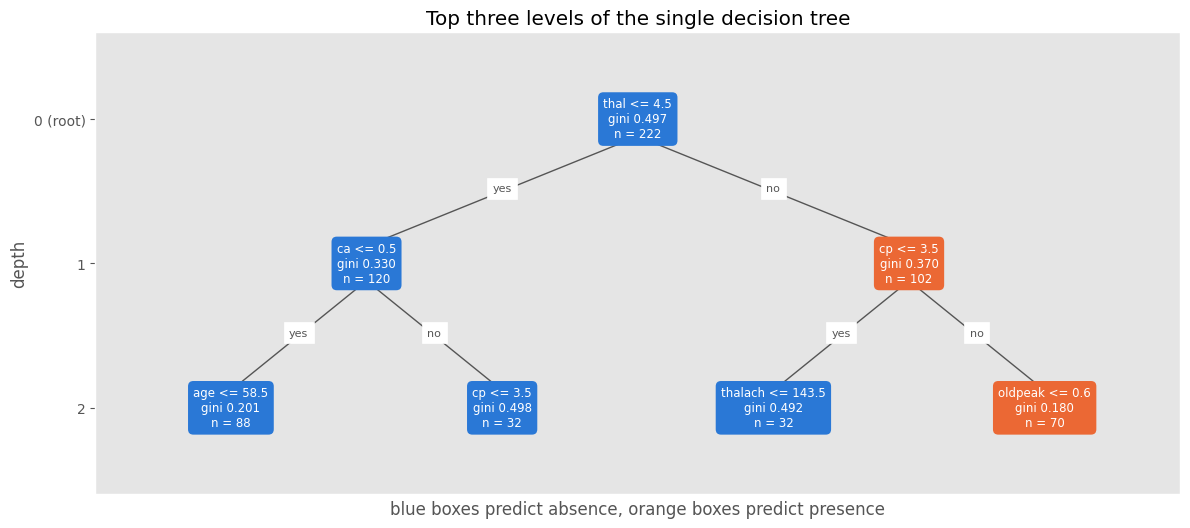

the same tree as text, one level deeper:

thal <= 4.5   gini 0.497, n = 222
   ca <= 0.5   gini 0.330, n = 120
      age <= 58.5   gini 0.201, n = 88
         -> absence  (gini 0.061, n = 64)  [splits further below]
         -> absence  (gini 0.444, n = 24)  [splits further below]
      cp <= 3.5   gini 0.498, n = 32
         -> absence  (gini 0.408, n = 21)  [splits further below]
         -> presence  (gini 0.298, n = 11)  [splits further below]
   cp <= 3.5   gini 0.370, n = 102
      thalach <= 143.5   gini 0.492, n = 32
         -> presence  (gini 0.320, n = 10)  [splits further below]
         -> absence  (gini 0.397, n = 22)  [splits further below]
      oldpeak <= 0.6   gini 0.180, n = 70
         -> presence  (gini 0.469, n = 16)  [splits further below]
         -> presence  (gini 0.036, n = 54)  [splits further below]


In [8]:
def node_label(node):
    if node['leaf']:
        name = 'absence' if node['value'] == 0 else 'presence'
        return f"predict {name}\ngini {node['gini']:.3f}\nn = {node['n']}"
    return (f"{feature_names[node['feature']]} <= {node['threshold']:.1f}\n"
            f"gini {node['gini']:.3f}\nn = {node['n']}")


def draw(ax, node, depth, slot, max_depth):
    x = (slot + 0.5) / (2 ** depth)
    y = -depth
    colour = BLUE if node['value'] == 0 else ORANGE

    if not node['leaf'] and depth < max_depth:
        for child, child_slot in [(node['left'], 2 * slot), (node['right'], 2 * slot + 1)]:
            cx = (child_slot + 0.5) / (2 ** (depth + 1))
            ax.plot([x, cx], [y - 0.12, y - 0.88], color='#555555', linewidth=1)
            side = 'yes' if child_slot % 2 == 0 else 'no'
            ax.text((x + cx) / 2, y - 0.5, side, fontsize=8, color='#555555',
                    ha='center', backgroundcolor='white')
            draw(ax, child, depth + 1, child_slot, max_depth)

    ax.text(x, y, node_label(node), ha='center', va='center', fontsize=8.5, color='white',
            bbox=dict(boxstyle='round,pad=0.45', facecolor=colour, edgecolor='none'))


def show_text(node, depth, max_depth, prefix=''):
    if node['leaf'] or depth == max_depth:
        name = 'absence' if node['value'] == 0 else 'presence'
        # a node cut off by max_depth is not a real leaf, so say which it is
        tail = '' if node['leaf'] else '  [splits further below]'
        print(f"{prefix}-> {name}  (gini {node['gini']:.3f}, n = {node['n']}){tail}")
        return
    print(f"{prefix}{feature_names[node['feature']]} <= {node['threshold']:.1f}"
          f"   gini {node['gini']:.3f}, n = {node['n']}")
    show_text(node['left'], depth + 1, max_depth, prefix + '   ')
    show_text(node['right'], depth + 1, max_depth, prefix + '   ')


fig, ax = plt.subplots(figsize=(14, 6))
draw(ax, tree.root, 0, 0, 2)
ax.set_xlim(0, 1)
ax.set_ylim(-2.6, 0.6)
ax.set_xticks([])
ax.set_yticks([0, -1, -2])
ax.set_yticklabels(['0 (root)', '1', '2'])
ax.set_xlabel('blue boxes predict absence, orange boxes predict presence')
ax.set_ylabel('depth')
ax.set_title('Top three levels of the single decision tree')
ax.grid(False)
plt.show()

print('the same tree as text, one level deeper:')
print()
show_text(tree.root, 0, 3)

## Why one tree is not enough

A deep tree has low bias and high variance: change a handful of training rows and the split chosen
at the root can change, which rewrites every split below it. Averaging many such trees is what a
forest does, and the reason it works is the variance of an average.

Take $T$ identically distributed predictions, each with variance $\sigma^2$, with pairwise
correlation $\rho$ between any two. The variance of their average is

$$\operatorname{Var}\left(\frac{1}{T}\sum_{t=1}^{T} h_t\right) = \rho\sigma^2 + \frac{1 - \rho}{T}\sigma^2$$

Increasing $T$ drives the second term to zero, but the first term does not move. **Averaging more
trees only helps up to the point set by how correlated they are with each other**, which is why the
accuracy curve further down flattens rather than continuing to climb. Reducing $\rho$ is the other
half of the job, and the forest attacks it twice:

- **Bootstrap sampling.** Each tree is fitted on $n$ rows drawn from the $n$ training rows *with
  replacement*, so each tree sees a slightly different dataset.
- **Random feature subsets.** Each split considers only $\sqrt{p}$ of the $p$ features, chosen
  fresh at every node. Without this, one dominant feature would be picked at the root of nearly
  every tree and the trees would look alike no matter how the rows were resampled.

Predictions are combined by majority vote across the trees,

$$\hat{y} = \arg\max_c \sum_{t=1}^{T} \mathbb{1}[h_t(x) = c]$$

The bootstrap also hands over a free validation set. A given row survives one draw with probability
$1 - 1/n$, so the probability it is missed by all $n$ draws is

$$\left(1 - \frac{1}{n}\right)^{n} \xrightarrow[n \to \infty]{} e^{-1} \approx 0.368$$

Roughly 37% of the rows are **out-of-bag** for each tree. Predicting each row using only the trees
that never saw it gives an honest estimate of generalisation accuracy without holding anything back.

In [9]:
n = len(X_train)
print('n =', n)
print('P(row is out-of-bag for a given tree) = (1 - 1/n)^n =', round((1 - 1 / n) ** n, 4))
print('limit e^-1 =', round(np.exp(-1), 4))

n = 222
P(row is out-of-bag for a given tree) = (1 - 1/n)^n = 0.367
limit e^-1 = 0.3679


## The Random_Forest class

`fit` loops `n_trees` times. Each pass draws `idx = rng.integers(0, n, size=n)`, which is the
bootstrap sample - `n` row indices drawn with replacement, so some rows appear several times and
others not at all. A `Decision_Tree` is built on those rows with `n_features` set to
$\lfloor\sqrt{p}\rfloor$, which is 3 here, and each tree gets its own seed drawn from the forest's
generator so the feature subsets differ between trees. The tree and the indices it used are stored.

`importances` averages the per-tree importance vectors, so a feature scores highly only if it was
useful across many different resamplings and feature subsets.

`tree_votes` returns the raw `(n_trees, n_samples)` matrix of individual tree predictions. `predict`
averages it down the tree axis and thresholds at 0.5, which for two classes is exactly the majority
vote. It takes an optional `n_trees` argument so the first $t$ trees can be scored without refitting.

`compute_oob` builds the out-of-bag estimate. For each tree it marks every row not in that tree's
bootstrap indices, predicts those rows with that tree alone, and adds the result into a per-row vote
tally. Once every tree has contributed, each row is decided by the majority of the trees that
excluded it, and the accuracy over those rows is the OOB score.

In [10]:
class Random_Forest:
    def __init__(self, n_trees=100, max_depth=10, min_samples_split=2, n_features=None,
                 random_state=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.random_state = random_state

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n = len(y)

        if self.n_features is None:
            k = max(1, int(np.sqrt(X.shape[1])))
        else:
            k = self.n_features

        self.trees = []
        self.bootstrap_rows = []

        for _ in range(self.n_trees):
            idx = rng.integers(0, n, size=n)          # bootstrap: n rows, with replacement
            tree = Decision_Tree(max_depth=self.max_depth,
                                 min_samples_split=self.min_samples_split,
                                 n_features=k,
                                 random_state=int(rng.integers(0, 2 ** 31 - 1)))
            tree.fit(X[idx], y[idx])
            self.trees.append(tree)
            self.bootstrap_rows.append(idx)

        self.n_features_used = k
        self.importances = np.mean([t.importances for t in self.trees], axis=0)
        self.oob_score = self.compute_oob(X, y)
        return self

    def tree_votes(self, X):
        return np.array([t.predict(X) for t in self.trees])

    def predict(self, X, n_trees=None):
        votes = self.tree_votes(X)
        if n_trees is not None:
            votes = votes[:n_trees]
        return (votes.mean(axis=0) > 0.5).astype(int)

    def compute_oob(self, X, y):
        n = len(y)
        votes = np.zeros((n, 2))

        for tree, idx in zip(self.trees, self.bootstrap_rows):
            oob = np.ones(n, dtype=bool)
            oob[idx] = False                          # rows this tree never saw
            if oob.sum() == 0:
                continue
            rows = np.where(oob)[0]
            votes[rows, tree.predict(X[rows])] += 1

        scored = votes.sum(axis=1) > 0
        predicted = np.argmax(votes[scored], axis=1)
        self.oob_rows = scored.sum()
        return (predicted == y[scored]).mean()

## Fitting the forest

100 trees on 222 rows. The cell times the fit, then reports test accuracy, the OOB score and the
average fraction of rows left out of each bootstrap, which should land near the 0.368 predicted
above.

In [11]:
import time

start = time.time()
forest = Random_Forest(n_trees=100, max_depth=10, random_state=42)
forest.fit(X_train, y_train)
elapsed = time.time() - start

forest_test_acc = (forest.predict(X_test) == y_test).mean()
oob_fraction = np.mean([1 - len(np.unique(idx)) / len(y_train) for idx in forest.bootstrap_rows])

print(f'fitted {forest.n_trees} trees in {elapsed:.2f} s')
print('features considered per split:', forest.n_features_used, 'of', len(feature_names))
print()
print('single tree test accuracy: ', round(tree_test_acc, 4))
print('forest test accuracy:      ', round(forest_test_acc, 4))
print('forest OOB score:          ', round(forest.oob_score, 4))
print()
print('mean out-of-bag fraction per tree:', round(oob_fraction, 4))

fitted 100 trees in 0.48 s
features considered per split: 3 of 13

single tree test accuracy:  0.7733
forest test accuracy:       0.8667
forest OOB score:           0.8333

mean out-of-bag fraction per tree: 0.37


## Accuracy against the number of trees

`tree_votes` is computed once and the running mean over the first $t$ rows of that matrix gives the
majority vote of the first $t$ trees, so the whole curve costs one pass over the test set rather
than 100 refits.

The single-tree accuracy and the OOB score are drawn on as horizontal references. The curve is
jagged at the left, where adding one tree can flip several votes, and settles as $T$ grows. It
flattens rather than continuing to rise, which is the $\rho\sigma^2$ term in the variance formula:
once the averaging has removed the $\frac{1-\rho}{T}\sigma^2$ part there is nothing left for extra
trees to do.

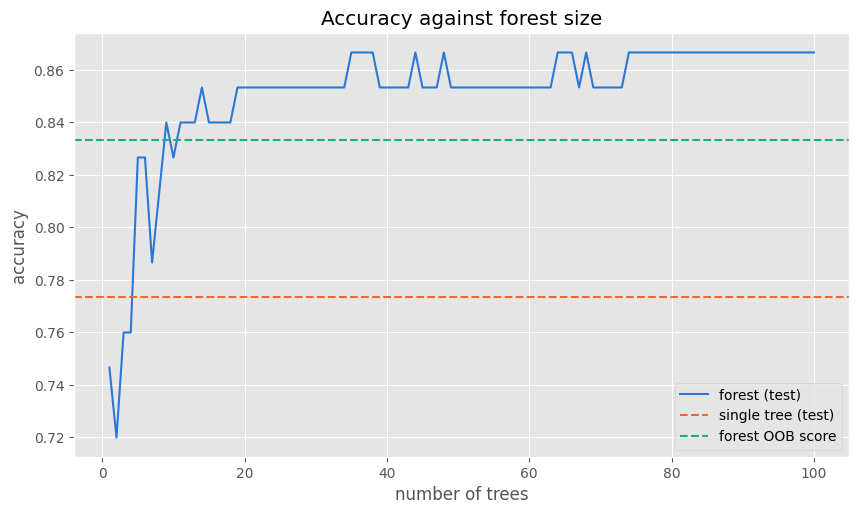

   1 trees: 0.7467
   5 trees: 0.8267
  10 trees: 0.8267
  25 trees: 0.8533
  50 trees: 0.8533
 100 trees: 0.8667


In [12]:
votes = forest.tree_votes(X_test)
running = np.cumsum(votes, axis=0) / np.arange(1, forest.n_trees + 1)[:, None]
acc_by_trees = ((running > 0.5).astype(int) == y_test).mean(axis=1)

plt.figure(figsize=(10, 5.5))
plt.plot(range(1, forest.n_trees + 1), acc_by_trees, color=BLUE, label='forest (test)')
plt.axhline(tree_test_acc, color=ORANGE, linestyle='--', label='single tree (test)')
plt.axhline(forest.oob_score, color=AQUA, linestyle='--', label='forest OOB score')
plt.xlabel('number of trees')
plt.ylabel('accuracy')
plt.title('Accuracy against forest size')
plt.legend()
plt.show()

for t in [1, 5, 10, 25, 50, 100]:
    print(f'{t:>4} trees: {acc_by_trees[t - 1]:.4f}')

## Feature importance

`forest.importances` is the average across the 100 trees of the impurity decrease each feature
produced, weighted by the samples reaching each node. The cell sorts it and draws it as a horizontal
bar chart alongside the same quantity for the single tree.

The single tree's version is the spikier of the two. It splits on `thal` at the root, which hands
that one feature 0.30 of the total - more than twice the forest's largest score - and leaves
`restecg` at exactly zero, never chosen anywhere in the tree. The forest spreads the weight out: a
feature that a stronger one would have shadowed still gets to be the best available choice in the
trees where the stronger one was not among the 3 features sampled at that node. That makes the
forest ranking the more trustworthy of the two, though neither is evidence of anything causal.

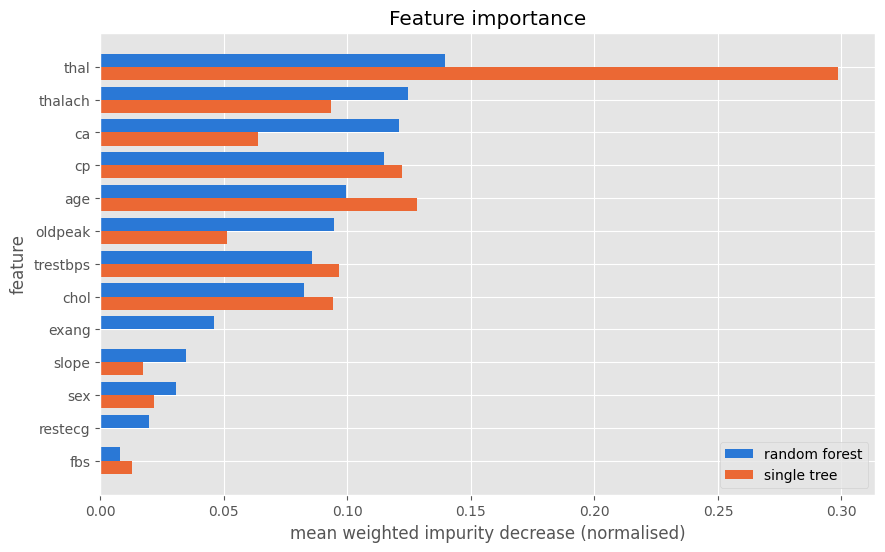

forest ranking:
  thal       0.1393
  thalach    0.1245
  ca         0.1209
  cp         0.1147
  age        0.0994
  oldpeak    0.0945
  trestbps   0.0855
  chol       0.0823
  exang      0.0459
  slope      0.0347
  sex        0.0306
  restecg    0.0197
  fbs        0.0080


In [13]:
order_imp = np.argsort(forest.importances)
names_sorted = [feature_names[i] for i in order_imp]
positions = np.arange(len(feature_names))

plt.figure(figsize=(10, 6))
plt.barh(positions + 0.2, forest.importances[order_imp], height=0.4, color=BLUE,
         label='random forest')
plt.barh(positions - 0.2, tree.importances[order_imp], height=0.4, color=ORANGE,
         label='single tree')
plt.yticks(positions, names_sorted)
plt.xlabel('mean weighted impurity decrease (normalised)')
plt.ylabel('feature')
plt.title('Feature importance')
plt.legend()
plt.show()

print('forest ranking:')
for i in order_imp[::-1]:
    print(f'  {feature_names[i]:<10} {forest.importances[i]:.4f}')

## Accuracy against tree depth

The cell sweeps `max_depth` from 1 to 15, and at each value fits one unrestricted tree and one
forest of 60 trees, recording training and test accuracy for both.

The single tree's training accuracy climbs to 1.0 and stays there - past a certain depth its leaves
are pure and it has memorised the 222 training rows. Its test accuracy peaks early and then falls
back, which is overfitting made visible. The forest's test accuracy rises and then holds roughly
flat: its trees individually overfit just as hard, but they overfit to different bootstrap samples
and different feature subsets, so the errors do not survive the vote.

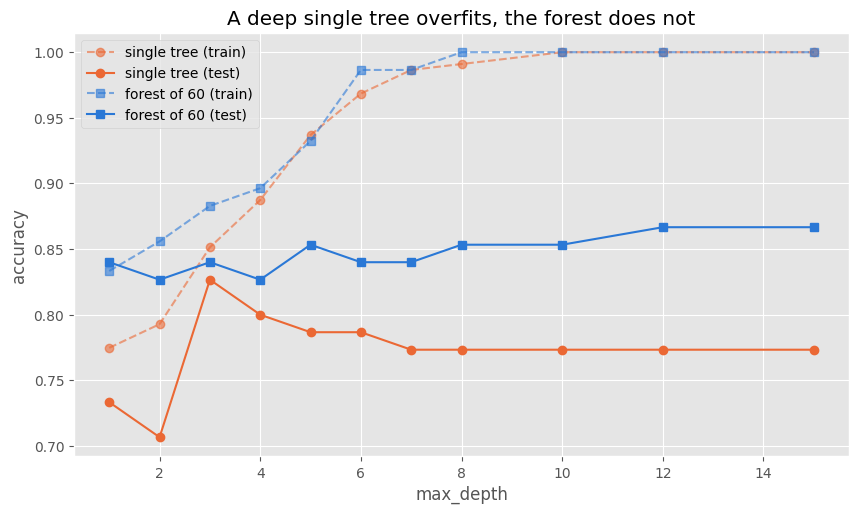

depth   tree train   tree test   forest train   forest test
    1       0.7748      0.7333         0.8333        0.8400
    2       0.7928      0.7067         0.8559        0.8267
    3       0.8514      0.8267         0.8829        0.8400
    4       0.8874      0.8000         0.8964        0.8267
    5       0.9369      0.7867         0.9324        0.8533
    6       0.9685      0.7867         0.9865        0.8400
    7       0.9865      0.7733         0.9865        0.8400
    8       0.9910      0.7733         1.0000        0.8533
   10       1.0000      0.7733         1.0000        0.8533
   12       1.0000      0.7733         1.0000        0.8667
   15       1.0000      0.7733         1.0000        0.8667


In [14]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15]
tree_train, tree_test, forest_train, forest_test = [], [], [], []

for d in depths:
    t = Decision_Tree(max_depth=d, random_state=1).fit(X_train, y_train)
    tree_train.append((t.predict(X_train) == y_train).mean())
    tree_test.append((t.predict(X_test) == y_test).mean())

    f = Random_Forest(n_trees=60, max_depth=d, random_state=42).fit(X_train, y_train)
    forest_train.append((f.predict(X_train) == y_train).mean())
    forest_test.append((f.predict(X_test) == y_test).mean())

plt.figure(figsize=(10, 5.5))
plt.plot(depths, tree_train, marker='o', linestyle='--', color=ORANGE, alpha=0.6,
         label='single tree (train)')
plt.plot(depths, tree_test, marker='o', color=ORANGE, label='single tree (test)')
plt.plot(depths, forest_train, marker='s', linestyle='--', color=BLUE, alpha=0.6,
         label='forest of 60 (train)')
plt.plot(depths, forest_test, marker='s', color=BLUE, label='forest of 60 (test)')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.title('A deep single tree overfits, the forest does not')
plt.legend()
plt.show()

print('depth   tree train   tree test   forest train   forest test')
for i, d in enumerate(depths):
    print(f'{d:>5}   {tree_train[i]:>10.4f}   {tree_test[i]:>9.4f}   '
          f'{forest_train[i]:>12.4f}   {forest_test[i]:>11.4f}')

## Confusion matrix

The counts are accumulated by incrementing `matrix[true, predicted]` for every test patient, then
drawn with `imshow` and annotated. The diagonal is correct, the off-diagonal is not.

The two error types are not equally serious here. The top-right cell is a patient with no heart
disease flagged as having it, and the bottom-left cell is a patient with heart disease reported as
clear - the second is the one that matters clinically, and it is worth reading which of the two the
model produces more of.

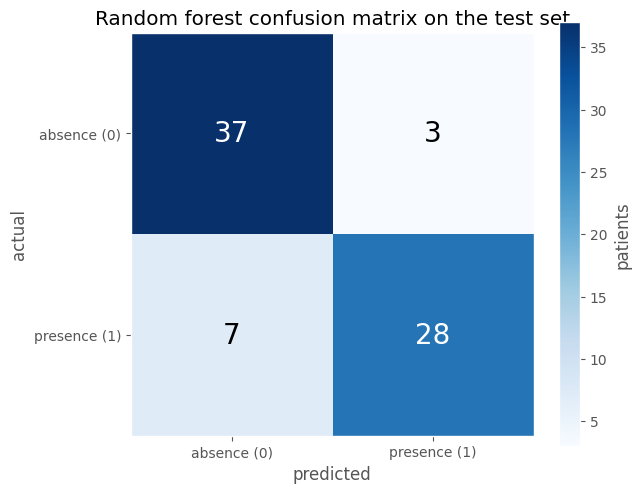

correct: 65 of 75
accuracy:  0.8667
missed heart disease (false negatives): 7
false alarms (false positives):         3
recall on presence: 0.8
precision on presence: 0.9032


In [15]:
predicted = forest.predict(X_test)

matrix = np.zeros((2, 2), dtype=int)
for true_label, pred_label in zip(y_test, predicted):
    matrix[true_label, pred_label] += 1

labels = ['absence (0)', 'presence (1)']

plt.figure(figsize=(6.5, 5.5))
plt.imshow(matrix, cmap='Blues')
plt.colorbar(label='patients')
plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('Random forest confusion matrix on the test set')
for i in range(2):
    for j in range(2):
        colour = 'white' if matrix[i, j] > matrix.max() / 2 else 'black'
        plt.text(j, i, matrix[i, j], ha='center', va='center', fontsize=20, color=colour)
plt.grid(False)
plt.show()

true_neg, false_pos = matrix[0]
false_neg, true_pos = matrix[1]

print('correct:', true_neg + true_pos, 'of', len(y_test))
print('accuracy: ', round((true_neg + true_pos) / len(y_test), 4))
print('missed heart disease (false negatives):', false_neg)
print('false alarms (false positives):        ', false_pos)
print('recall on presence:', round(true_pos / (true_pos + false_neg), 4))
print('precision on presence:', round(true_pos / (true_pos + false_pos), 4))

## Summary

- A decision tree splits on `feature <= threshold`, choosing at every node the split that maximises
  $\Delta G = G(\text{parent}) - \frac{n_L}{n}G(L) - \frac{n_R}{n}G(R)$ with
  $G = 1 - \sum_c p_c^2$. Thresholds are midpoints between neighbouring observed values, and the
  leaves store the majority class.
- No scaling was applied, because a split only ever compares a feature against a threshold in that
  same feature's units.
- A single tree at `max_depth=10` reaches 1.0 on the training set and 0.7733 on the test set. The
  depth sweep shows its test accuracy peaking at `max_depth=3` and falling away after, while the
  forest holds flat from there on.
- The forest fits 100 trees, each on a bootstrap sample of the 222 training rows and each split
  restricted to $\lfloor\sqrt{13}\rfloor = 3$ random features, then takes the majority vote
  $\hat{y} = \arg\max_c \sum_t \mathbb{1}[h_t(x) = c]$. It beats the single tree by roughly nine
  points.
- The averaging argument $\operatorname{Var} = \rho\sigma^2 + \frac{1-\rho}{T}\sigma^2$ explains
  both halves of the design. More trees remove the second term, which is why the accuracy curve
  plateaus; the random feature subsets lower $\rho$, which is the only way to reduce what is left.
- Roughly 37% of rows are out-of-bag for each tree, matching $(1 - 1/n)^n \to e^{-1}$, and scoring
  each row with only the trees that excluded it gives a validation estimate for free. It came out a
  few points below the test accuracy here, which is the expected direction - each OOB row is judged
  by only about a third of the forest.
- 297 rows is a small dataset and the test set is 75 patients, so a single patient moves the score
  by 1.3 points. The numbers here should be read as mid-80s rather than as an exact figure.